# Análise da métrica Line-Breaking Pass Value 

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import math
import ipywidgets as widgets
from ipywidgets import interact
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

from utils.utils import draw_pitch, plot_pass_on_pitch, add_pitch_legend, pass_title, pitch_legend_handles
# Configurar estilo visual e fontes 

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


/Users/goncalo.rodrigues9/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/21/7hv4zdjs1xg_628k1767wlpc0000gn/T/matplotlib-_6glurgu because there was an issue with the default path (/Users/goncalo.rodrigues9/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


In [2]:
# carregar tabelas
linebreaking_df = pd.read_parquet('../data/processed/line_breaking_passes.parquet')
events = pd.read_parquet('../data/processed/events.parquet')
matches_df = pd.read_parquet('../data/processed/matches.parquet')

# Visualização da métrica

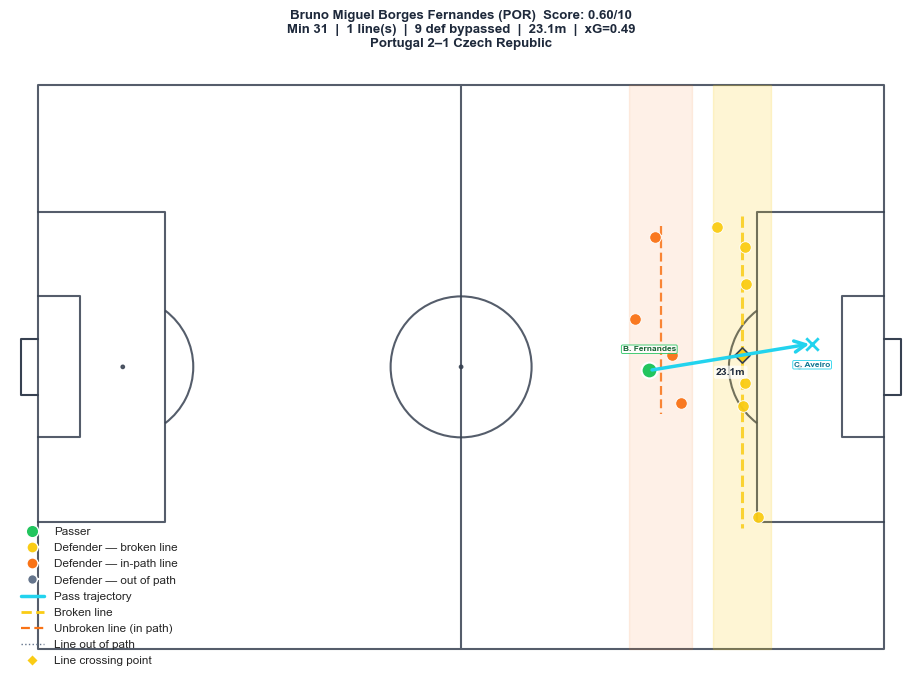

In [3]:
# Interativo: visualiza qualquer line breaking pass ordenada por Index (0 = maior score)
PASS_INDEX = 5

row_sel = linebreaking_df.nlargest(len(linebreaking_df), 'score').iloc[PASS_INDEX]


fig, ax = plt.subplots(figsize=(10, 7))
plot_pass_on_pitch(ax, row_sel, events, title=pass_title(row_sel, matches_df))
ax.legend(handles=pitch_legend_handles(),
          loc='lower left', fontsize=8.5, framealpha=0.0, edgecolor='none')
plt.tight_layout()
plt.show()

Este exemplo permite perceber visualmente quase todos os conceitos utilizados na métrica Line-Breaking Pass Value. O passe realizado por Bruno Fernandes é identificado como um passe line-breaking porque cumpre simultaneamente os critérios geométricos definidos anteriormente.

O jogador em verde representa o passador e a linha azul corresponde à trajetória do passe. Os jogadores a laranja representam defesas presentes no trajeto do passe, enquanto os jogadores cinzentos (não presentes neste exemplo) representam adversários fora desse corredor de progressão. 

Os jogadores adversários estão agrupados em diferentes zonas sombreadas geradas pelo cluster através da proximidade no eixo X e que representam o espaço ocupado por cada linha defensiva. As linhas verticais tracejadas representam a posição média (`line_x`) de cada uma dessas zonas e o losango amarelo indica o ponto onde a trajetória do passe intersecta a linha quebrada. 

Neste caso existem duas linhas relevantes:

- uma linha laranja, que apesar de estar no trajeto do passe e ser quebrada, estava a menos de 5 metros do jogador que realizou o passe, não cumprindo um dos critérios geométricos definidos;
- uma linha amarela, que é efetivamente quebrada e que cumpre os restantes critérios geométricos, indicando que o passe é classificado como line-breaking.

Assim, não são consideradas quebras de linha passes que apenas contornam lateralmente a estrutura defensiva, passes dirigidos para adversários posicionados atrás do passador, ou situações em que o ponto de interseção ocorre demasiado próximo da origem do passe, tornando a quebra da linha trivial do ponto de vista tático.

O gráfico apresenta também informação contextual utilizada no score final.

Neste exemplo o passe ultrapassa `9` adversários (`def bypassed`) e quebra `1` linha defensiva. 

- `23.1m` corresponde à progressão territorial do passe;
- `xG = 0.49` indica que a jogada originou posteriormente uma finalização de elevado perigo;
- `Score: 0.60/1` representa o valor final calculado pela combinação ponderada das diferentes componentes da métrica.

Assim, este exemplo demonstra que a métrica não avalia apenas a distância do passe, mas também:

- o contexto posicional;
- a estrutura defensiva penetrada;
- o número de adversários eliminados;
- e a consequência ofensiva gerada pela ação.

### Análise de Distribuições da Métrica

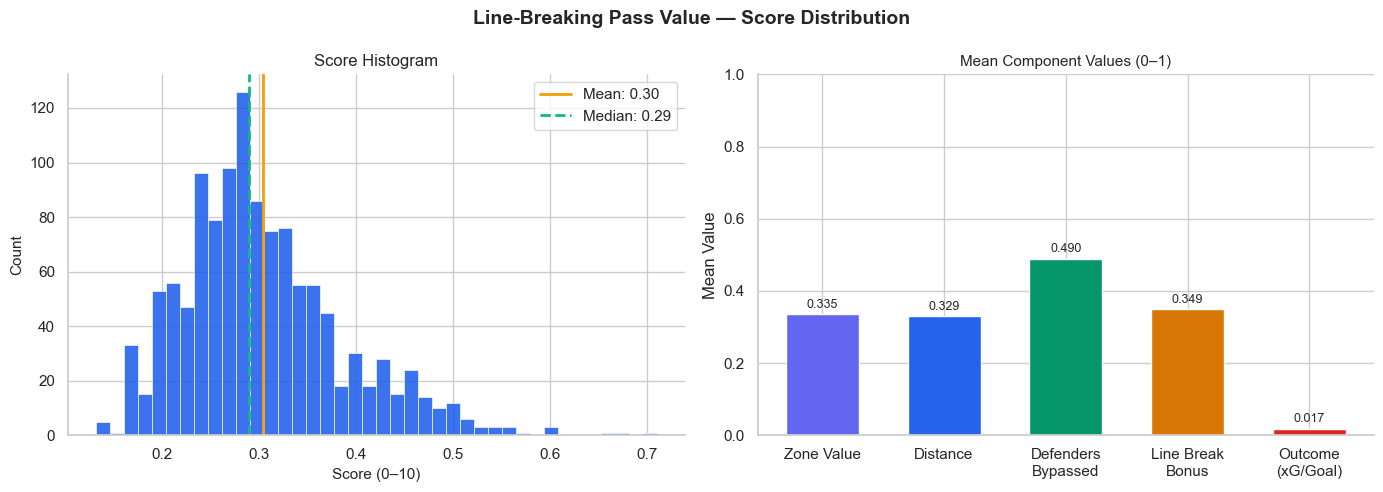

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Line-Breaking Pass Value — Score Distribution', fontsize=14, fontweight='bold')

# Histograma
ax = axes[0]
ax.hist(linebreaking_df['score'], bins=40, color='#2563eb', edgecolor='white', linewidth=0.5, alpha=0.9)
ax.axvline(linebreaking_df['score'].mean(), color='#f59e0b', linewidth=2, label=f"Mean: {linebreaking_df['score'].mean():.2f}")
ax.axvline(linebreaking_df['score'].median(), color='#10b981', linewidth=2, linestyle='--', label=f"Median: {linebreaking_df['score'].median():.2f}")
ax.set_xlabel('Score (0–10)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Score Histogram')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Gráfico de barras - valor médio dos componentes
ax2 = axes[1]
components = ['zone_value', 'distance_norm', 'defenders_norm', 'line_break_norm', 'outcome_norm']
labels = ['Zone Value', 'Distance', 'Defenders\nBypassed', 'Line Break\nBonus', 'Outcome\n(xG/Goal)']
colors = ['#6366f1', '#2563eb', '#059669', '#d97706', '#dc2626']
means = [linebreaking_df[c].mean() for c in components]
bars = ax2.bar(labels, means, color=colors, edgecolor='white', width=0.6)
ax2.set_title('Mean Component Values (0–1)', fontsize=11)
ax2.set_ylabel('Mean Value')
ax2.set_ylim(0, 1)
for bar, val in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}',
             ha='center', va='bottom', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

De modo a compreender melhor o comportamento da métrica e contextualizar os resultados obtidos, foi construído um histograma da distribuição dos scores finais. Este tipo de gráfico permite visualizar a frequência de ocorrência dos diferentes valores da métrica, facilitando a análise da dispersão, concentração e presença de ações com impacto mais elevado. Adicionalmente, foi também construído um gráfico de barras com os valores médios das diferentes componentes do score, permitindo perceber quais os fatores que mais contribuem, em média, para o valor final da métrica.

Pela análise do histograma concluimos que a maioria dos passes encontra-se concentrada entre aproximadamente 0.20 e 0.40, com média (0.30) e mediana (0.29) muito próximas, indicando uma distribuição relativamente equilibrada. Os scores mais elevados são raros e correspondem a ações com maior impacto contextual, normalmente associadas a elevada progressão, múltiplas linhas quebradas e consequência ofensiva relevante.

Já a análise do gráfico de barras explica que a componente com maior valor médio é Defenders Bypassed (0.490), sugerindo que os passes identificados tendem a ultrapassar vários adversários. As restantes componentes (Zone Value, Distance e Line Break Bonus) apresentam valores relativamente equilibrados, enquanto Outcome (0.017) tem um valor médio reduzido, refletindo o facto de apenas uma pequena percentagem destes passes resultar diretamente em remates ou golos.

# Análise Euro 2024

## Países Baixos 2–3 Áustria

Será agora apresentada uma análise detalhada dos passes line-breaking de ambas as equipas neste jogo, incluindo médias por equipa e jogador, bem como visualizações em pitch dos golos da partida.
Este jogo foi selecionado por incluir vários golos originados em sequências com passes que quebram linhas, tornando-o particularmente relevante para demonstrar a aplicação prática da métrica desenvolvida.

In [5]:
MATCH_ID  = 3930180          

# Obter informações do jogo de forma automática
matches_all = pd.read_parquet('../data/processed/matches.parquet')
match_info = matches_all[matches_all['match_id'] == MATCH_ID].iloc[0]
HOME_TEAM = match_info['home_team']
AWAY_TEAM = match_info['away_team']
SCORE = f"{int(match_info['home_score'])}-{int(match_info['away_score'])}"

print(f"Jogo: {HOME_TEAM} {SCORE} {AWAY_TEAM}")

# filtrar o jogo
match_df = linebreaking_df[linebreaking_df['match_id'] == MATCH_ID].copy()

Jogo: Netherlands 2-3 Austria


In [6]:
# Golos do jogo com line breaking passes
goals = (
    events[
        (events['match_id'] == MATCH_ID) &
        (events['type'] == 'Shot') &
        (events['shot_outcome'] == 'Goal') &
        (events['actor'] == True)
    ][['id', 'team', 'player', 'minute', 'second', 'possession', 'shot_statsbomb_xg']]
    .drop_duplicates()
    .sort_values('minute')
    .reset_index(drop=True)
)

# Melhor LBP da posse do golo
goal_lbp = []
for _, goal in goals.iterrows():
    poss_ids = events[
        (events['match_id'] == MATCH_ID) &
        (events['possession'] == goal['possession']) &
        (events['type'] == 'Pass') &
        (events['actor'] == True)
    ]['id']
    lbp = match_df[match_df['id'].isin(poss_ids)]
    if not lbp.empty:
        goal_lbp.append((goal, lbp.nlargest(1, 'score').iloc[0]))

def plot_single_goal_lbp(index):
    if not goal_lbp:
        print("No goals with LBP found.")
        return
    goal, lbp_row = goal_lbp[index]
    fig, ax = plt.subplots(figsize=(9, 7))
    title = f"Goal: {goal['player'].split()[-1]} {int(goal['minute'])}'\n" + pass_title(lbp_row)
    plot_pass_on_pitch(ax, lbp_row, events, title=title)
    add_pitch_legend(fig, anchor=(0.5, -0.04))
    plt.tight_layout()
    plt.show()
    plt.close(fig) 

# Guarda imagem com todos os golos lado a lado
if len(goal_lbp) > 0:
    n_goals = len(goal_lbp)
    fig_save, axes_save = plt.subplots(1, n_goals, figsize=(n_goals * 10, 7))
    fig_save.suptitle(f'{HOME_TEAM} {SCORE} {AWAY_TEAM} — Goals & Line-Breaking Passes',
                      fontsize=14, fontweight='bold', y=1.01)
    if n_goals == 1:
        axes_save = [axes_save]
    for ax, (goal, lbp_row) in zip(axes_save, goal_lbp):
        title = f"Goal: {goal['player'].split()[-1]} {int(goal['minute'])}'\n" + pass_title(lbp_row)
        plot_pass_on_pitch(ax, lbp_row, events, title=title)
    add_pitch_legend(fig_save, anchor=(0.5, -0.04))
    plt.tight_layout()
    plt.close(fig_save)

# Slider interativo para png
if len(goal_lbp) > 0:
    interact(plot_single_goal_lbp, index=widgets.IntSlider(min=0, max=len(goal_lbp)-1, step=1, value=0, description='Goal:'))
else:
    print('No goals with LBP visualised.')

interactive(children=(IntSlider(value=0, description='Goal:', max=2), Output()), _dom_classes=('widget-interac…

A figura apresenta três golos do jogo Países Baixos 2-3 Áustria que foram antecedidos por passes classificados como line-breaking. Este resultado é particularmente relevante, uma vez que, num jogo com cinco golos, três tiveram origem em ações capazes de penetrar estruturalmente a organização defensiva adversária. Este comportamento reforça a utilidade da métrica, mostrando que os passes identificados não representam apenas progressão territorial, mas estão frequentemente associados à criação de situações ofensivas de elevado perigo.

Dois dos exemplos pertencem à Áustria e ambos ocorrem já no último terço ofensivo. Nestes casos, os passes conseguem quebrar a última linha defensiva neerlandesa em zonas próximas da área, criando imediatamente condições favoráveis para finalização. No lance de Christoph Baumgartner, o passe quebra uma linha composta por vários defesas posicionados perto da área, ultrapassa 7 adversários e corresponde diretamente à assistência para o golo de Sabitzer, sendo por isso um dos exemplos mais claros do impacto ofensivo capturado pela métrica.

No caso do passe de Alexander Prass, a ação quebra igualmente a última linha defensiva e antecede imediatamente o cruzamento que resulta no golo austríaco. Apesar de o lance ter sido registado oficialmente como autogolo, a jogada gera uma situação com xG = 0.60, evidenciando o elevado perigo criado pela sequência ofensiva iniciada pelo passe line-breaking.

O exemplo de Stefan de Vrij é distinto, mas também relevante do ponto de vista contextual. Embora o passe não origine um remate nos 10 segundos seguintes (No shot) e apresente um score inferior, a ação permite à Holanda ultrapassar a pressão austríaca e entrar no meio-campo ofensivo na posse que posteriormente resulta em golo. Isto demonstra que nem todos os passes que quebram linhas têm impacto imediato em termos de finalização, mas podem continuar a desempenhar um papel importante na progressão e destabilização da estrutura defensiva adversária.

No geral, estes exemplos mostram que a métrica consegue capturar diferentes tipos de passes line-breaking:

- ações de progressão intermédia;
- passes de penetração no último terço;
- passes diretamente associados a assistências;
- passes que antecedem remates de elevado perigo;
- e ações diretamente relacionadas com golos.

Além disso, reforçam a ideia de que a quebra de linhas defensivas constitui frequentemente um elemento importante na criação de vantagem ofensiva em contexto competitivo de alto nível.

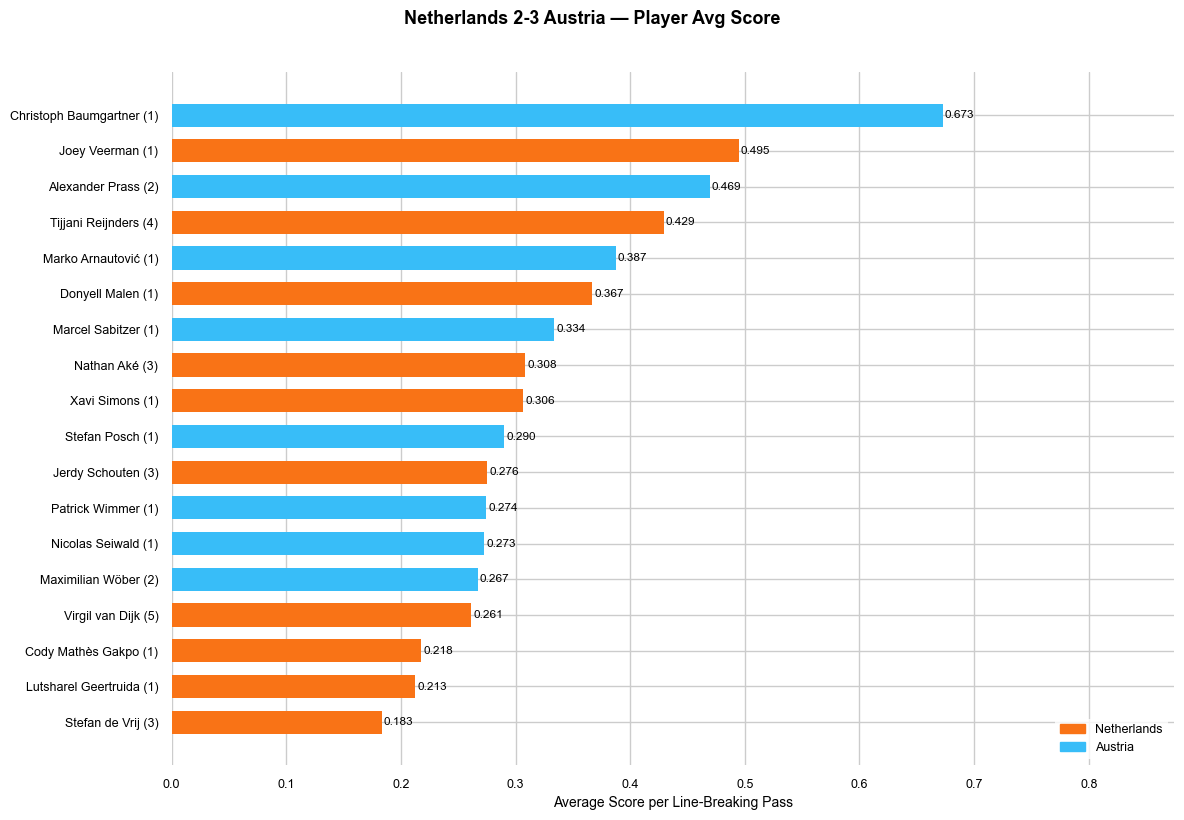

In [7]:
# Stats dos jogadores
player_stats = (
    match_df.groupby(['player', 'team'])
    .agg(
        n_passes   = ('score', 'count'),
        score_mean = ('score', 'mean'),
        score_max  = ('score', 'max'),
    )
    .reset_index()
    .sort_values('score_mean', ascending=True)
)

BG, CARD = 'white', 'white'
NED_COL, AUT_COL = '#f97316', '#38bdf8'
team_colors = {HOME_TEAM: NED_COL, AWAY_TEAM: AUT_COL}
colors = [team_colors[t] for t in player_stats['team']]

fig, ax = plt.subplots(figsize=(12, max(5, len(player_stats) * 0.45)), facecolor=BG)
ax.set_facecolor(CARD)
fig.suptitle(f'{HOME_TEAM} {SCORE} {AWAY_TEAM} — Player Avg Score',
             color='black', fontsize=13, fontweight='bold', y=1.01)

labels = [f"{r['player']} ({r['n_passes']})" for _, r in player_stats.iterrows()]
bars = ax.barh(labels, player_stats['score_mean'], color=colors, edgecolor='none', height=0.65)

for bar, (_, r) in zip(bars, player_stats.iterrows()):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{r['score_mean']:.3f}", va='center', color='black', fontsize=8.5)

ax.set_xlabel('Average Score per Line-Breaking Pass', color='black', fontsize=10)
ax.tick_params(colors='black', labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xlim(0, player_stats['score_mean'].max() * 1.3)

# Legend
ned_patch = mpatches.Patch(color=NED_COL, label=HOME_TEAM)
aut_patch = mpatches.Patch(color=AUT_COL, label=AWAY_TEAM)
ax.legend(handles=[ned_patch, aut_patch], loc='lower right',
          facecolor='white', edgecolor='none', labelcolor='black', fontsize=9)

plt.tight_layout()
plt.show()


O gráfico apresenta o score médio dos passes line-breaking realizados por cada jogador no jogo entre Países Baixos e Áustria, com o número de passes identificado entre parênteses.

Christoph Baumgartner apresenta o maior score médio (0.673), embora com apenas um passe identificado. Esse passe corresponde diretamente à assistência para o golo de Sabitzer, justificando o elevado valor obtido.

Alexander Prass também se destaca com dois passes line-breaking e média de 0.469. Um desses passes antecede o cruzamento que resulta no autogolo neerlandês, mostrando que a métrica consegue capturar ações de elevado impacto ofensivo mesmo quando não existe assistência direta registada.

Do lado neerlandês, Tijjani Reijnders destaca-se pela combinação entre volume e qualidade, realizando 4 passes line-breaking com média de 0.429, evidenciando consistência na progressão ofensiva através do passe.

Os centrais neerlandeses também apresentam valores relevantes. Van Dijk realizou 5 passes line-breaking, enquanto Aké e De Vrij realizaram 3 cada, reforçando o papel destes jogadores na construção desde trás e na superação da primeira linha de pressão austríaca.

# Análise Competição

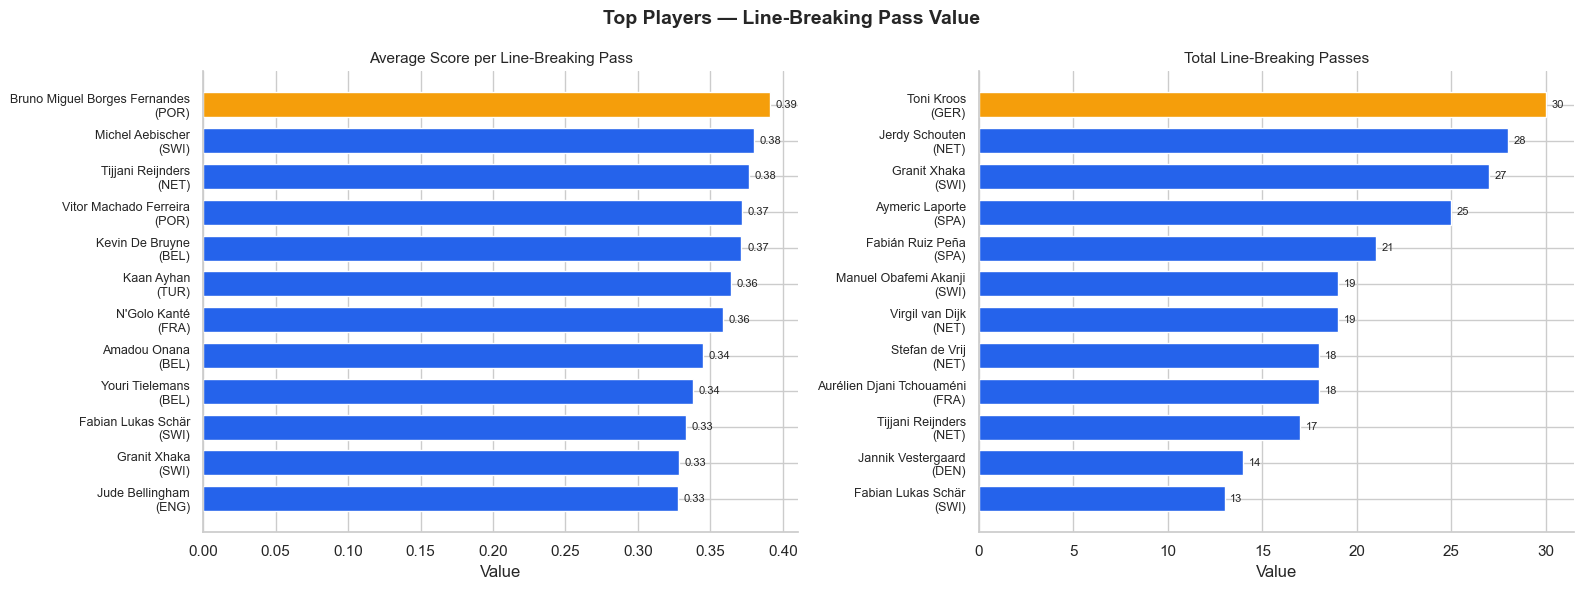

In [8]:
# calcular stats por jogador e filtar jogadores com no mínimo 7 passes que quebram linhas
player_stats = (
    linebreaking_df.groupby(['player', 'team'])
    .agg(
        count=('score', 'count'),
        score_total=('score', 'sum'),
        score_mean=('score', 'mean'),
        score_max=('score', 'max'),
        lines_broken_avg=('lines_broken', 'mean'),
        defenders_bypassed_avg=('n_defenders_bypassed', 'mean'),
        pct_with_outcome=('outcome_value', lambda x: (x > 0).mean() * 100),
    )
    .reset_index()
    .query('count >= 7')
    .sort_values('score_total', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top Players — Line-Breaking Pass Value', fontsize=14, fontweight='bold')

top_mean  = player_stats.nlargest(12, 'score_mean')
top_count = player_stats.nlargest(12, 'count')

for ax, data, col, title, color in [
    (axes[0], top_mean,  'score_mean', 'Average Score per Line-Breaking Pass', '#2563eb'),
    (axes[1], top_count, 'count', 'Total Line-Breaking Passes', '#2563eb'),
]:

    labels = [
        f"{r['player']}\n({r['team'][:3].upper()})"
        for _, r in data.iterrows()
    ]

    values = data[col].values

    colors_bar = [color] * len(values)
    colors_bar[0] = '#f59e0b'

    bars = ax.barh(
        range(len(labels)),
        values[::-1],
        color=colors_bar[::-1],
        edgecolor='white',
        height=0.7
    )

    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels[::-1], fontsize=9)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Value')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, val in zip(bars, values[::-1]):
        ax.text(
            bar.get_width() + values.max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}' if col != 'count' else f'{int(val)}',
            va='center',
            fontsize=8
        )

plt.tight_layout()
plt.show()

Observa-se que os jogadores que mais se destacam na métrica LBPV correspondem a médios e jogadores com forte capacidade de progressão e construção, como Bruno Fernandes, Reijnders, Kevin De Bruyne ou Vitinha. Isto é expectável, uma vez que estes jogadores participam frequentemente em fases de construção ofensiva e procuram passes verticais capazes de ultrapassar linhas defensivas. Bruno Fernandes surge com o maior score médio (0.39), indicando que, apesar de não ser o jogador com maior volume, os seus passes line-breaking tendem a apresentar elevado impacto contextual segundo a métrica.

Já no gráfico da direita, que representa volume total de ações, continuam a aparecer médios organizadores como Toni Kroos, Xhaka ou Fabián Ruiz, mas surgem também vários defesas centrais, como Akanji, Van Dijk, De Vrij e Laporte. Este comportamento é particularmente interessante, pois sugere que muitos centrais participaram ativamente na construção desde trás, realizando passes que ultrapassam a primeira linha de pressão adversária. Toni Kroos destaca-se claramente com 30 passes line-breaking identificados, reforçando o seu perfil como um dos principais organizadores e progressores do torneio. Granit Xhaka também merece destaque por aparecer simultaneamente nos dois gráficos, combinando elevado volume com boa qualidade média dos passes realizados.

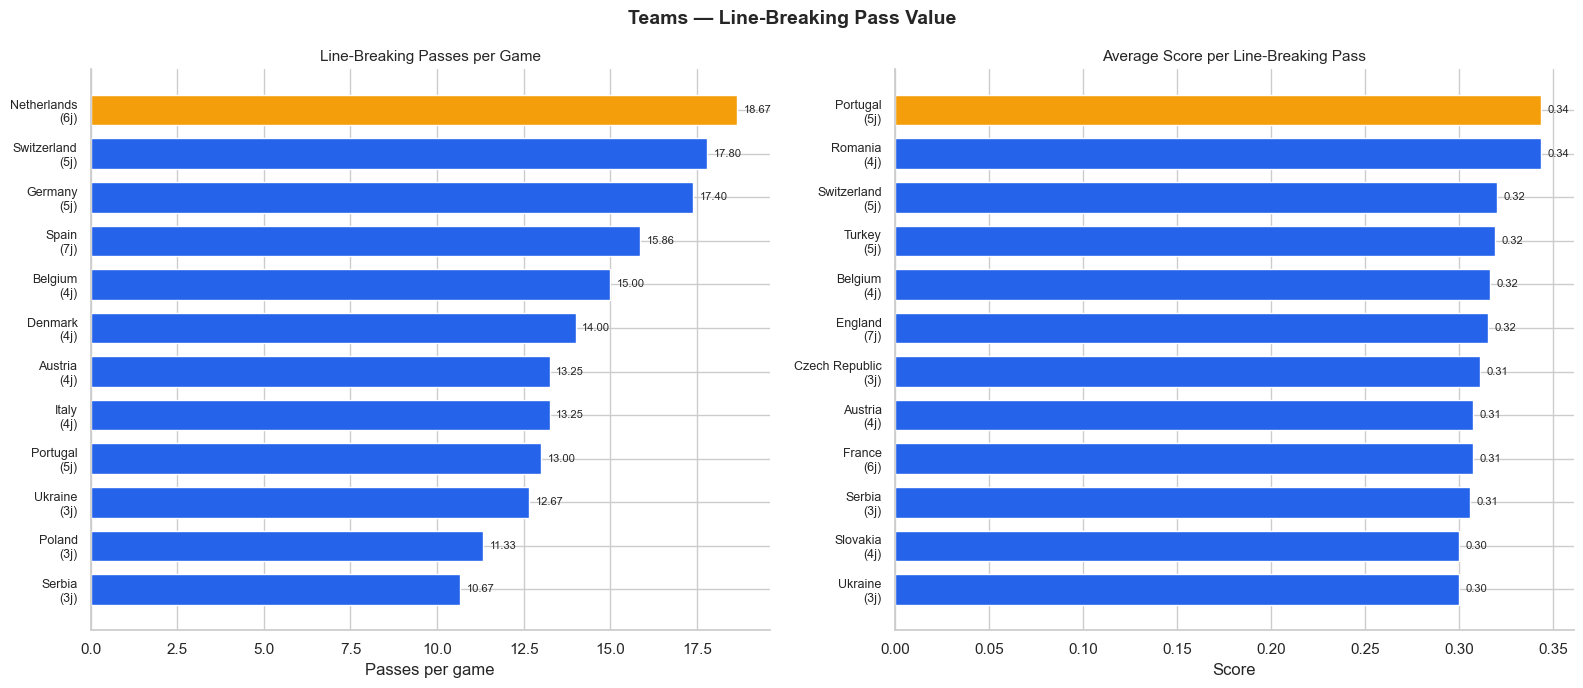

In [9]:
# calcular stats por equipa
team_stats = (
    linebreaking_df.groupby("team")
    .agg(
        n_passes=("score", "count"),
        n_games=("match_id", "nunique"),
        score_mean=("score", "mean"),
        score_sum=("score", "sum"),
        def_bypassed_avg=("n_defenders_bypassed", "mean"),
        pct_outcome=("outcome_value", lambda x: (x > 0).mean() * 100),
    )
    .reset_index()
)

team_stats["passes_per_game"] = team_stats["n_passes"] / team_stats["n_games"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Teams — Line-Breaking Pass Value", fontsize=14, fontweight="bold")

top_ppg  = team_stats.nlargest(12, "passes_per_game")
top_mean = team_stats.nlargest(12, "score_mean")

for ax, data, col, title, xlabel in [
    (axes[0], top_ppg,  "passes_per_game", "Line-Breaking Passes per Game", "Passes per game"),
    (axes[1], top_mean, "score_mean", "Average Score per Line-Breaking Pass", "Score"),
]:

    labels = [
        f"{r['team']}\n({int(r['n_games'])}j)"
        for _, r in data.iterrows()
    ]

    values = data[col].values

    colors_bar = ["#2563eb"] * len(values)
    colors_bar[0] = "#f59e0b"

    bars = ax.barh(
        range(len(labels)),
        values[::-1],
        color=colors_bar[::-1],
        edgecolor="white",
        height=0.7
    )

    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels[::-1], fontsize=9)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bar, val in zip(bars, values[::-1]):
        ax.text(
            bar.get_width() + values.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

O gráfico da esquerda apresenta as equipas com maior número médio de passes line-breaking por jogo durante o Euro 2024. Os Países Baixos destacam-se claramente com 18.67 passes por jogo em 6 jogos, seguidos pela Suíça, Alemanha e Espanha, o que destaca o imapcto da métrica em equipas de topo e sugere uma capacidade consistente de progressão através do passe ao longo de todo o torneio. 

O gráfico da direita representa o score médio dos passes line-breaking realizados por cada equipa, refletindo mais a qualidade contextual média das ações do que o volume total. Portugal surge no topo juntamente com a Roménia. A presença de equipas com menos jogos deve ser interpretada com alguma cautela, uma vez que amostras menores tendem a produzir médias mais voláteis. Ainda assim, os resultados sugerem que equipas como Portugal, Suíça e Bélgica não apenas produziram um volume relevante de passes de rutura, mas também ações com elevado impacto contextual médio segundo a métrica desenvolvida.